# Diabetes Risk Prediction Using Logistic Regression

## Project Overview

This project develops a machine learning model to estimate the likelihood of diabetes based on patient health measurements.

The project uses the Pima Indians Diabetes Dataset and focuses on the development of a Logistic Regression classification model.

### Project Objectives

The main objectives are to:

- Perform exploratory data analysis (EDA)
- Identify and handle data quality issues
- Investigate missing and invalid values
- Understand relationships between patient features and diabetes outcome
- Build a Logistic Regression classification model
- Evaluate model performance using:
  - Accuracy
  - Precision
  - Recall
  - ROC-AUC
- Use cross-validation and hyperparameter tuning to improve model reliability
- Evaluate different classification thresholds
- Produce a confusion matrix and ROC curve
- Save the final trained model
- Deploy the model through a simple Streamlit web application

### Expected Outcome

The final project aims to produce a trained classification model and an interactive web application that allows users to enter patient measurements and receive a predicted diabetes risk.

> **Important:** This project is intended for educational and portfolio purposes. The model is not a medical diagnostic tool.

## Import Libraries

In [1]:
# !pip install kagglehub

In [2]:
import os
import joblib
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import (
    train_test_split, 
    StratifiedKFold, 
    cross_validate, 
    GridSearchCV, 
    cross_val_predict)
from sklearn.metrics import ( 
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    auc)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline


# kagglehub.login()

## 3. Load Dataset

The dataset used in this project is the Pima Indians Diabetes Dataset.

It contains information about female patients and includes several medical diagnostic measurements along with a binary diabetes outcome.

In [3]:
from kagglehub import KaggleDatasetAdapter
# Download latest version
path = kagglehub.dataset_download("jamaltariqcheema/pima-indians-diabetes-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Raptor225\.cache\kagglehub\datasets\jamaltariqcheema\pima-indians-diabetes-dataset\versions\1


In [4]:
df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS,"jamaltariqcheema/pima-indians-diabetes-dataset","diabetes.csv")

print("First 5 Records:", df.head())

C:\Users\Raptor225\AppData\Local\Temp\ipykernel_9200\4060436516.py:1: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS,"jamaltariqcheema/pima-indians-diabetes-dataset","diabetes.csv")


First 5 Records:    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0             35    169.5  33.6   
1            1       85           66.0             29    102.5  26.6   
2            8      183           64.0             32    169.5  23.3   
3            1       89           66.0             23     94.0  28.1   
4            0      137           40.0             35    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


## 4. Dataset Overview

Before building the model, the dataset is examined to understand its structure, data types, statistical properties and target distribution.

### Feature Separation

In [5]:
# Number of rows and columns
print("Dataset shape:",df.shape)

# Display column names
print("\nColumn names:")
print(df.columns.tolist())

#check the data type and npn-null values
print("\nDataset infomation")
df.info()

#Generate descreptive statistics
print("\nDescriptive statistics:")
print(df.describe())

Dataset shape: (768, 9)

Column names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Dataset infomation
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB

Descriptive statistics:
       Pregnancies     Glucose 

### Target Distribution

The target variable `Outcome` contains two classes:

- `0` — No diabetes
- `1` — Diabetes

There are 500 observations with an outcome of 0 and 268 observations with an outcome of 1.

This represents a moderately imbalanced target distribution, which makes metrics such as precision, recall and ROC-AUC useful in addition to accuracy.

In [6]:
print("\nOutcome distribution:")
print(df["Outcome"].value_counts())

print("\nOutcome percentages:")
print(df["Outcome"].value_counts(normalize=True)*100)


Outcome distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Outcome percentages:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


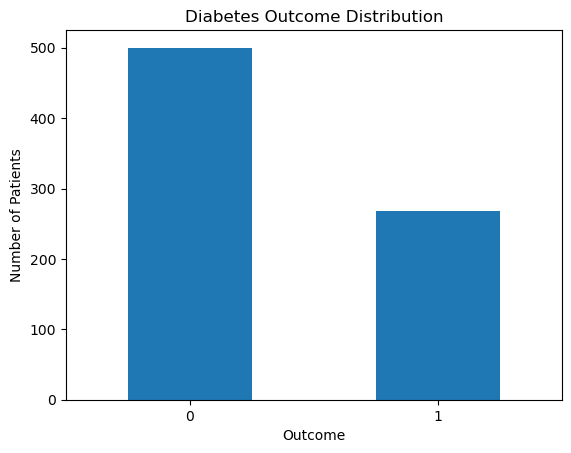

In [7]:
df["Outcome"].value_counts().plot(kind="bar")

plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)

plt.show()

## 5. Data Quality and Cleaning

The dataset contains no explicit null values, but some medical measurements contain zero values that may represent missing or invalid measurements rather than genuine physiological values.

In [8]:
zero_counts = (df==0).sum()
print("\nNumber of zero values per column:")
print(zero_counts)


Number of zero values per column:
Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


### Interpretation of Zero Values

Zero values are valid for `Pregnancies` and `Outcome`, so these values should not be treated as missing.

However, zero values in medical measurements such as glucose, blood pressure, BMI, skin thickness and insulin may represent missing measurements.

These values should therefore be investigated before modelling.

In [9]:
missing_values = df.isnull().sum()

print("Missing values per column:")
print(missing_values)

print("\nTotal missing values:")
print(df.isnull().sum().sum())

Missing values per column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Total missing values:
0


### Missing Value Analysis

No explicit missing values were present in the dataset. Therefore, no missing-value imputation was required.

In [10]:
duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 0


No duplicate records were identified, so no duplicate rows were removed.

### Target distribution

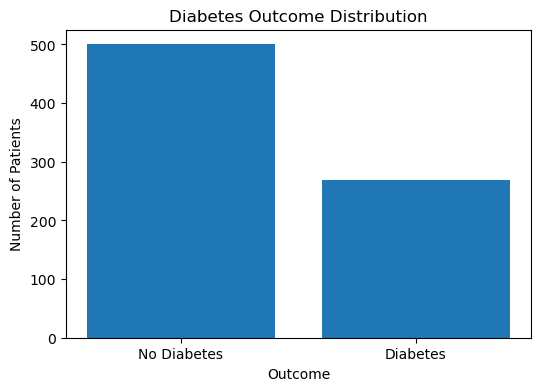

In [11]:
outcome_counts = df["Outcome"].value_counts()

plt.figure(figsize=(6, 4))

plt.bar(
    ["No Diabetes", "Diabetes"],
    outcome_counts.values
)

plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")

plt.show()

In [12]:
outcome_percentages = df["Outcome"].value_counts(normalize=True) * 100

print("Outcome percentages:")
print(outcome_percentages)

Outcome percentages:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


#### The dataset contains 768 observations, of which 500 (65.1%) are classified as non-diabetic and 268 (34.9%) as diabetic. The target variable is therefore moderately imbalanced, making metrics such as precision, recall and ROC-AUC important alongside accuracy.

## Let's see what the individual variables look like using Feature Distributions

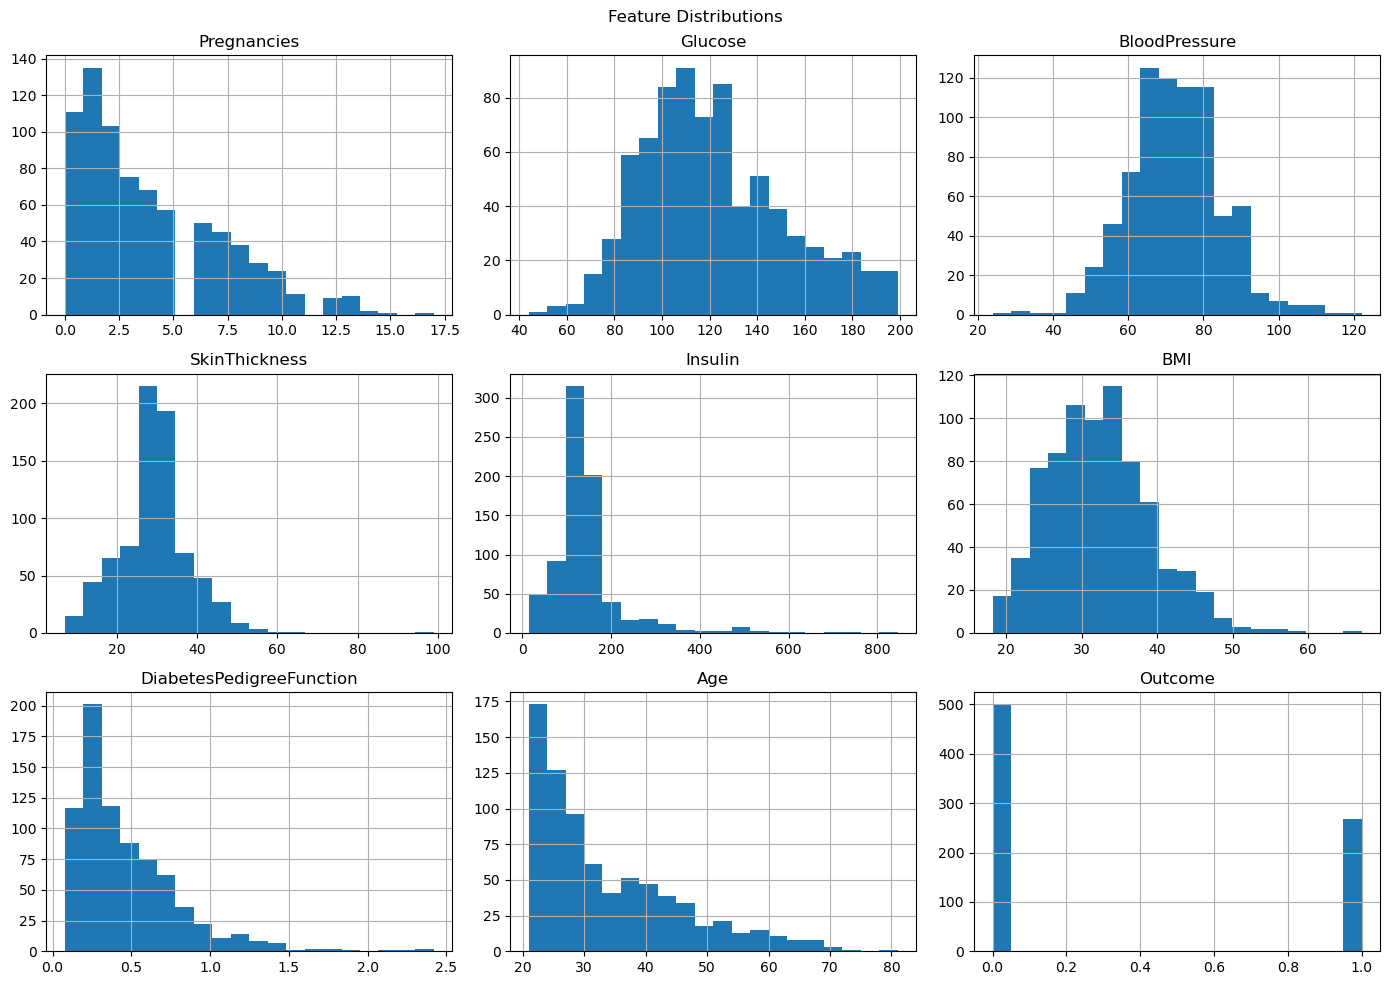

In [13]:
df.hist(figsize=(14,10), bins=20)

plt.suptitle("Feature Distributions")

plt.tight_layout()

plt.show()

## Let's identify potential outliers

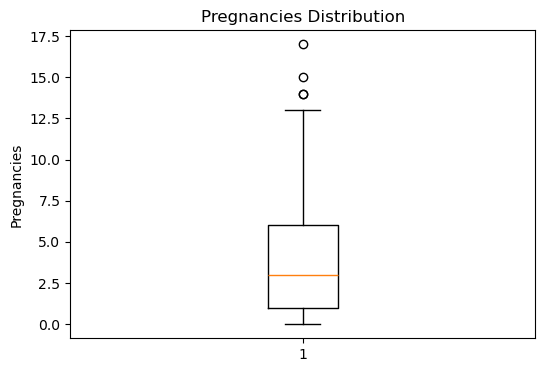

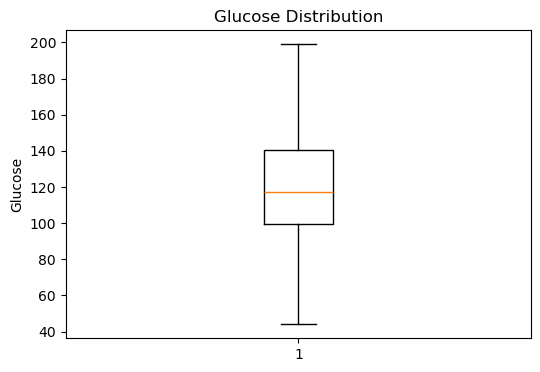

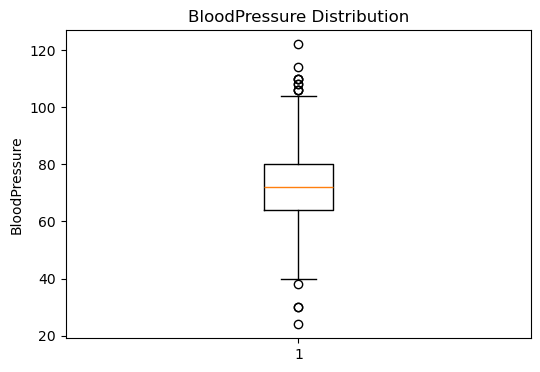

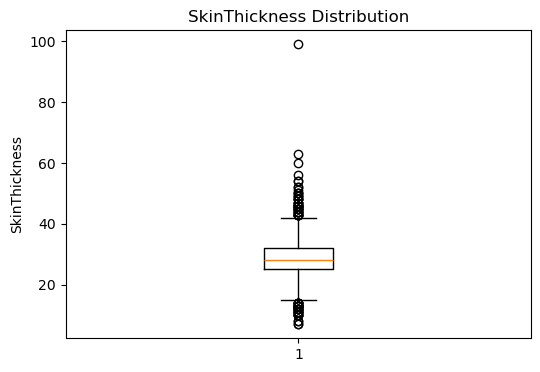

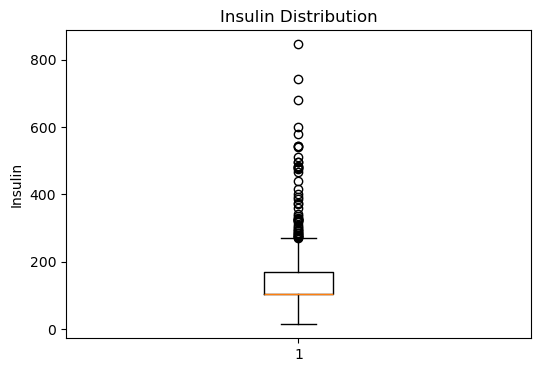

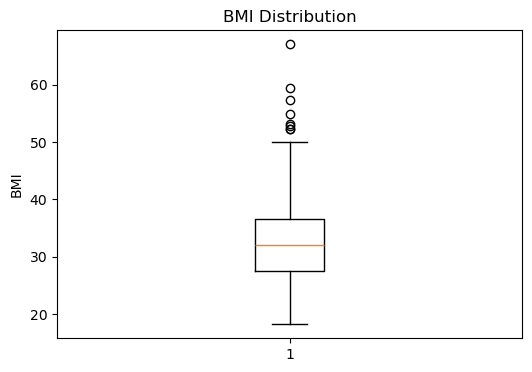

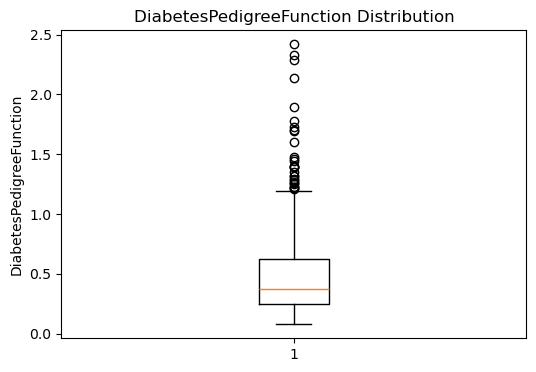

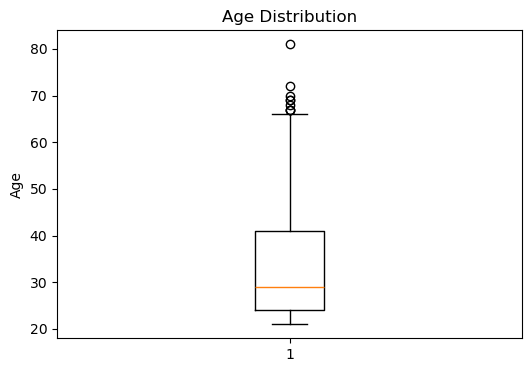

In [14]:
features = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

for feature in features:
    plt.figure(figsize=(6, 4))

    plt.boxplot(df[feature])

    plt.title(f"{feature} Distribution")
    plt.ylabel(feature)

    plt.show()

In [15]:
correlation_matrix = df.corr()

print(correlation_matrix["Outcome"].sort_values(ascending=False))

Outcome                     1.000000
Glucose                     0.495990
Insulin                     0.377081
BMI                         0.315577
SkinThickness               0.295138
Age                         0.238356
Pregnancies                 0.221898
BloodPressure               0.174469
DiabetesPedigreeFunction    0.173844
Name: Outcome, dtype: float64


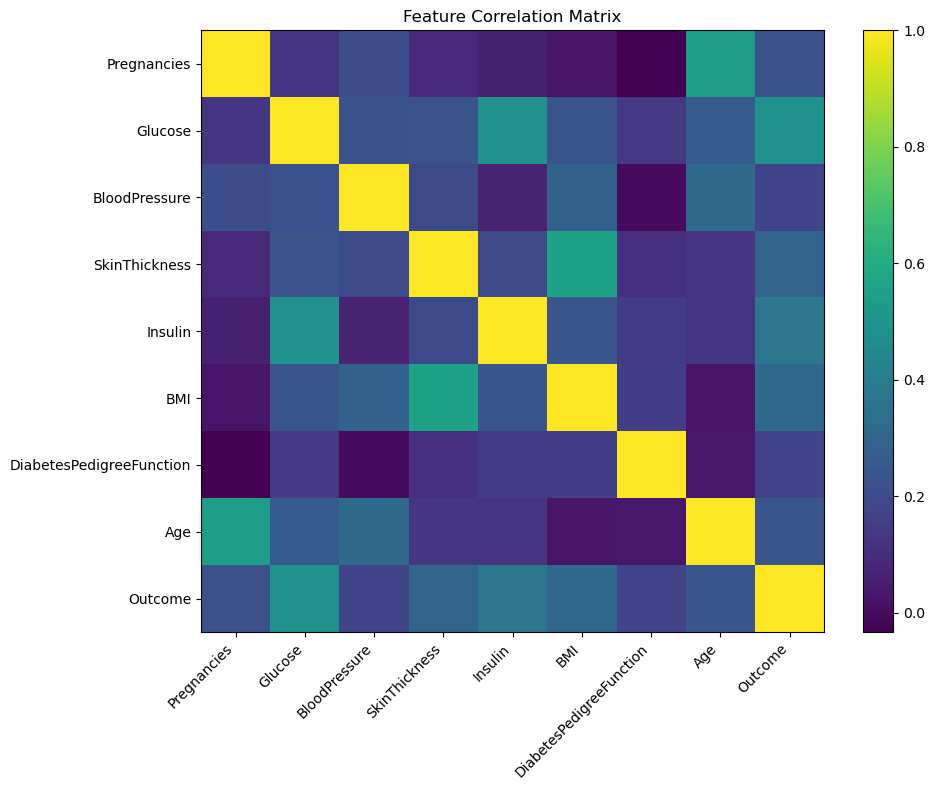

In [16]:
plt.figure(figsize=(10, 8))

plt.imshow(correlation_matrix, aspect="auto")

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Feature Correlation Matrix")

plt.tight_layout()

plt.show()

### Correlation Findings

Glucose has the strongest positive correlation with the diabetes outcome, followed by insulin and BMI.

However, correlation does not imply causation, and correlation alone is not sufficient for feature selection. All available predictor variables are therefore retained for the Logistic Regression model.

## Feature and Target Preparation

`Outcome` is used as the target variable, while the remaining eight variables are used as predictor features.

## Prepare data for Modelling

In [17]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (768, 8)
Target shape: (768,)


### Split the data into training and testing dataset

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# stratify=y ensures that the training and testing sets maintain approximately the same class proportions.

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (614, 8)
Testing set: (154, 8)


### Feature Scaling
#### Only using standard scalar on training data

In [19]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
# scaler.fit_transform(X_train)
logistic_model = LogisticRegression()
logistic_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [21]:
# scaler.fit_transform(X_test)

## 7. Logistic Regression Model

Logistic Regression was selected because this is a binary classification problem.

A `Pipeline` was used to combine feature standardization and Logistic Regression. This ensures that preprocessing is performed consistently during training, cross-validation and prediction.

The model was later tuned using cross-validation.

In [22]:
# Create the model
logistic_model = LogisticRegression(random_state=42)

# Train the model
logistic_model.fit(X_train_scaled, y_train)

print("Model training complete.")

Model training complete.


### Make predictions

In [23]:
# Generate class predictions
y_pred = logistic_model.predict(X_test_scaled)

# Generate probabilities
y_pred_probability = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("First 10 predictions:")
print(y_pred[:10])

print("\nFirst 10 predicted probabilities:")
print(y_pred_probability[:10])

First 10 predictions:
[0 0 0 0 0 0 1 1 0 1]

First 10 predicted probabilities:
[0.47739551 0.07407477 0.37011559 0.33773074 0.03196289 0.10346784
 0.55984821 0.90195873 0.0672363  0.9042001 ]


#### Evaluate Accuracy

In [24]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Accuracy: {accuracy * 100:.2f}%")
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Precision: {precision*100:.2f}%")
print(f"Recall: {recall*100:.2f}%")
roc_auc = roc_auc_score(y_test, y_pred_probability)

print(f"ROC-AUC: {roc_auc*100:.2f}%")

Accuracy: 70.78%
Accuracy: 70.78%
Precision: 58.82%
Recall: 55.56%
ROC-AUC: 82.63%


### Baseline Model Results

The initial Logistic Regression model achieved an accuracy of 70.78% and a ROC-AUC of 82.63%.

Although the ROC-AUC indicated useful discriminatory ability, the accuracy, precision and recall left room for improvement.

In [25]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[79 21]
 [24 30]]


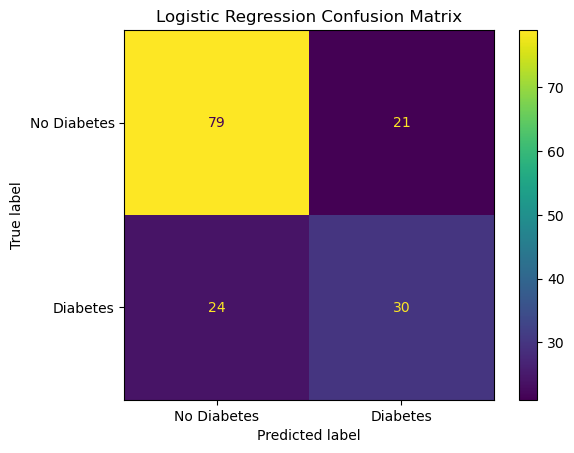

In [26]:
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Diabetes", "Diabetes"]
).plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [27]:
probability_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted_Probability": y_pred_probability,
    "Prediction": y_pred
})

print(probability_df.head(10))
print(probability_df["Predicted_Probability"].describe())

   Actual  Predicted_Probability  Prediction
0       0               0.477396           0
1       0               0.074075           0
2       0               0.370116           0
3       1               0.337731           0
4       0               0.031963           0
5       0               0.103468           0
6       1               0.559848           1
7       1               0.901959           1
8       0               0.067236           0
9       0               0.904200           1
count    154.000000
mean       0.370691
std        0.307576
min        0.016422
25%        0.080006
50%        0.302458
75%        0.626152
max        0.997962
Name: Predicted_Probability, dtype: float64


In [28]:
thresholds_to_test = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

results = []

for threshold in thresholds_to_test:

    predictions = (
        y_pred_probability >= threshold
    ).astype(int)

    results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0)
    })

threshold_results = pd.DataFrame(results)

print(threshold_results)

   Threshold  Accuracy  Precision    Recall
0       0.30  0.772727   0.623377  0.888889
1       0.35  0.746753   0.608696  0.777778
2       0.40  0.727273   0.596774  0.685185
3       0.45  0.707792   0.581818  0.592593
4       0.50  0.707792   0.588235  0.555556
5       0.55  0.720779   0.617021  0.537037
6       0.60  0.746753   0.682927  0.518519
7       0.65  0.753247   0.722222  0.481481
8       0.70  0.740260   0.718750  0.425926


In [29]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(random_state=42))
])
pipeline.fit(X_train, y_train)

print("Pipeline training complete.")
y_pred = pipeline.predict(X_test)

y_pred_probability = pipeline.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_probability)

print("Pipeline Model Evaluation")
print("-" * 35)
print(f"Accuracy : {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall   : {recall*100:.2f}%")
print(f"ROC-AUC  : {roc_auc*100:.2f}%")

Pipeline training complete.
Pipeline Model Evaluation
-----------------------------------
Accuracy : 70.78%
Precision: 58.82%
Recall   : 55.56%
ROC-AUC  : 82.63%


In [30]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "roc_auc": "roc_auc"
}

cv_results = cross_validate(
    pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

print("5-Fold Cross-Validation Results")
print("-" * 40)

for metric in scoring.keys():
    scores = cv_results[f"test_{metric}"]
    
    print(
        f"{metric.capitalize():10}: "
        f"{scores.mean()*100:.2f}% "
        f"± {scores.std()*100:.2f}%"
    )

5-Fold Cross-Validation Results
----------------------------------------
Accuracy  : 78.99% ± 1.60%
Precision : 74.87% ± 5.63%
Recall    : 60.76% ± 5.47%
Roc_auc   : 87.15% ± 1.67%


Five-fold cross-validation produced an average accuracy of approximately 79% and an average ROC-AUC of approximately 87%.

This provided stronger evidence that the model was learning a useful relationship between the features and the target rather than relying solely on a single train-test split.

In [31]:
param_grid = {
    "logistic_regression__C": [
        0.001,
        0.01,
        0.1,
        1,
        10,
        100
    ]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'logistic_regression__C': [0.001, 0.01, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [32]:
print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation ROC-AUC:")
print(grid_search.best_score_)

Best parameters:
{'logistic_regression__C': 0.1}

Best cross-validation ROC-AUC:
0.87312430786268


### Hyperparameter Tuning

Grid search was used to identify a suitable regularization parameter for Logistic Regression.

The best parameter was:

`C = 0.1`

The resulting cross-validation ROC-AUC was approximately 0.873.

In [33]:
best_pipeline = grid_search.best_estimator_

y_pred_tuned = best_pipeline.predict(X_test)

y_pred_probability_tuned = (
    best_pipeline.predict_proba(X_test)[:, 1]
)

accuracy_tuned = accuracy_score(
    y_test,
    y_pred_tuned
)

precision_tuned = precision_score(
    y_test,
    y_pred_tuned
)

recall_tuned = recall_score(
    y_test,
    y_pred_tuned
)

roc_auc_tuned = roc_auc_score(
    y_test,
    y_pred_probability_tuned
)

print("Tuned Logistic Regression")
print("-" * 35)
print(f"Accuracy : {accuracy_tuned*100:.2f}%")
print(f"Precision: {precision_tuned*100:.2f}%")
print(f"Recall   : {recall_tuned*100:.2f}%")
print(f"ROC-AUC  : {roc_auc_tuned*100:.2f}%")

Tuned Logistic Regression
-----------------------------------
Accuracy : 70.78%
Precision: 58.82%
Recall   : 55.56%
ROC-AUC  : 82.67%


In [34]:
final_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    (
        "logistic_regression",
        LogisticRegression(
            C=0.1,
            random_state=42
        )
    )
])

final_pipeline.fit(X_train, y_train)

print("Final model trained.")

Final model trained.


In [35]:
final_predictions = final_pipeline.predict(X_test)

final_probabilities = (
    final_pipeline.predict_proba(X_test)[:, 1]
)

final_accuracy = accuracy_score(
    y_test,
    final_predictions
)

final_precision = precision_score(
    y_test,
    final_predictions
)

final_recall = recall_score(
    y_test,
    final_predictions
)

final_roc_auc = roc_auc_score(
    y_test,
    final_probabilities
)

print("Final Logistic Regression Model")
print("-" * 40)
print(f"Accuracy : {final_accuracy*100:.2f}%")
print(f"Precision: {final_precision*100:.2f}%")
print(f"Recall   : {final_recall*100:.2f}%")
print(f"ROC-AUC  : {final_roc_auc*100:.2f}%")

Final Logistic Regression Model
----------------------------------------
Accuracy : 70.78%
Precision: 58.82%
Recall   : 55.56%
ROC-AUC  : 82.67%


## Classification Threshold Analysis

Logistic Regression produces a probability rather than simply a class label.

The default classification threshold is 0.50. However, different thresholds create different trade-offs between precision and recall.

Because identifying positive diabetes cases is important, several thresholds were evaluated using out-of-fold predictions.

In [36]:
cv_probabilities = cross_val_predict(
    final_pipeline,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba"
)[:, 1]

thresholds = [
    0.20,
    0.25,
    0.30,
    0.35,
    0.40,
    0.45,
    0.50,
    0.55,
    0.60,
    0.65,
    0.70
]

threshold_results = []

for threshold in thresholds:

    predictions = (
        cv_probabilities >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_train,
            predictions
        ),
        "Precision": precision_score(
            y_train,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_train,
            predictions,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

print(threshold_df)

    Threshold  Accuracy  Precision    Recall
0        0.20  0.705212   0.544715  0.939252
1        0.25  0.750814   0.593846  0.901869
2        0.30  0.781759   0.643885  0.836449
3        0.35  0.799674   0.688797  0.775701
4        0.40  0.798046   0.714286  0.700935
5        0.45  0.793160   0.730159  0.644860
6        0.50  0.791531   0.750000  0.602804
7        0.55  0.791531   0.775641  0.565421
8        0.60  0.796417   0.820144  0.532710
9        0.65  0.778502   0.819672  0.467290
10       0.70  0.758958   0.836735  0.383178


A threshold of 0.35 was selected because it provided a strong balance between accuracy and recall.

At this threshold, the out-of-fold results were approximately:

- Accuracy: 79.97%
- Precision: 68.88%
- Recall: 77.57%

The threshold was selected without using the final test set, preserving the test set for unbiased final evaluation.

In [37]:
final_probabilities = final_pipeline.predict_proba(X_test)[:, 1]

final_threshold = 0.35

final_predictions = (
    final_probabilities >= final_threshold
).astype(int)

final_accuracy = accuracy_score(
    y_test,
    final_predictions
)

final_precision = precision_score(
    y_test,
    final_predictions
)

final_recall = recall_score(
    y_test,
    final_predictions
)

final_roc_auc = roc_auc_score(
    y_test,
    final_probabilities
)

final_cm = confusion_matrix(
    y_test,
    final_predictions
)

print("FINAL MODEL EVALUATION")
print("=" * 40)
print(f"Threshold : {final_threshold}")
print(f"Accuracy  : {final_accuracy*100:.2f}%")
print(f"Precision : {final_precision*100:.2f}%")
print(f"Recall    : {final_recall*100:.2f}%")
print(f"ROC-AUC   : {final_roc_auc*100:.2f}%")

print("\nConfusion Matrix:")
print(final_cm)

FINAL MODEL EVALUATION
Threshold : 0.35
Accuracy  : 74.03%
Precision : 60.29%
Recall    : 75.93%
ROC-AUC   : 82.67%

Confusion Matrix:
[[73 27]
 [13 41]]


## Final Model Evaluation

After model selection and threshold selection, the final model was evaluated once on the previously unseen test dataset.

### Final Test Results

| Metric | Result |
|---|---:|
| Accuracy | 74.03% |
| Precision | 60.29% |
| Recall | 75.93% |
| ROC-AUC | 82.67% |

The model achieved a ROC-AUC of 82.67%, indicating good ability to distinguish between the two outcome classes.

The recall of 75.93% indicates that the model identified approximately three-quarters of the positive diabetes cases in the test set.

The final test accuracy of 74.03% was slightly below the initial target of 75%. However, cross-validation produced an average accuracy of approximately 79%, indicating that performance varies depending on the data split.

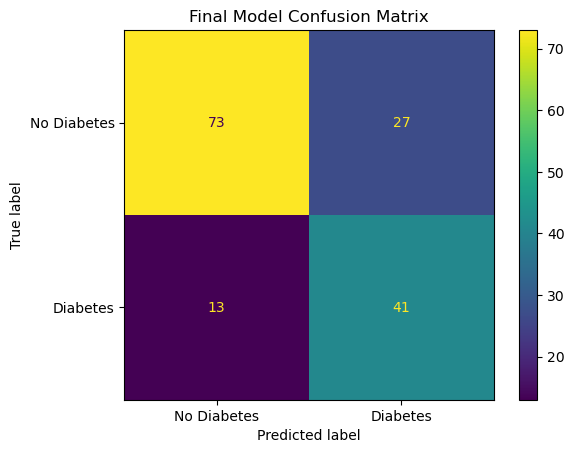

In [38]:
ConfusionMatrixDisplay(
    confusion_matrix=final_cm,
    display_labels=["No Diabetes", "Diabetes"]
).plot()

plt.title("Final Model Confusion Matrix")
plt.show()

### Confusion Matrix Interpretation

The final confusion matrix was:

[[73, 27],
 [13, 41]]

The model correctly classified:

- 73 non-diabetic patients
- 41 diabetic patients

It incorrectly classified:

- 27 non-diabetic patients as diabetic
- 13 diabetic patients as non-diabetic

The relatively low number of false negatives is consistent with the improved recall achieved by lowering the classification threshold to 0.35.

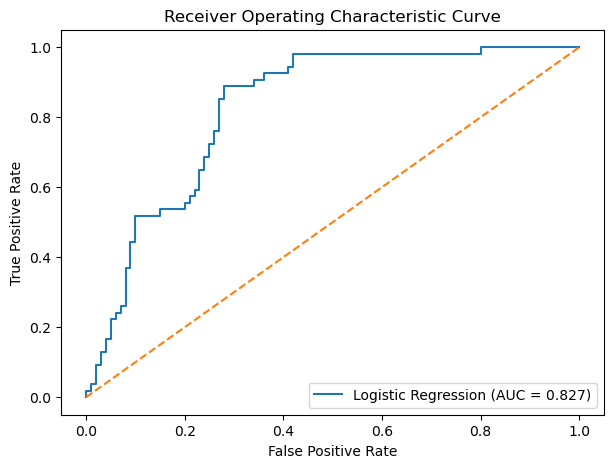

In [39]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    final_probabilities
)

roc_auc = roc_auc_score(
    y_test,
    final_probabilities
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Receiver Operating Characteristic Curve")

plt.legend()

plt.show()

### ROC-AUC Interpretation

The final model achieved a ROC-AUC of 0.827.

This indicates that the model has good discriminatory ability and performs substantially better than random classification.

# Conclusion

This project demonstrated an end-to-end machine learning workflow for diabetes risk prediction.

The process included exploratory data analysis, data quality assessment, feature preparation, Logistic Regression, feature scaling, cross-validation, hyperparameter tuning, classification threshold analysis and final model evaluation.

The final model achieved:

- **74.03% test accuracy**
- **60.29% test precision**
- **75.93% test recall**
- **82.67% test ROC-AUC**

Cross-validation produced an average accuracy of approximately 79% and ROC-AUC of approximately 87%.

A classification threshold of 0.35 was selected to improve recall compared with the default 0.50 threshold.

The trained model was serialized using Joblib and integrated into a Streamlit application that allows users to enter patient measurements and receive a predicted diabetes risk.

## Limitations

This project has several limitations:

- The dataset is relatively small, containing 768 observations.
- The model is trained on a specific historical dataset and may not generalize to other populations.
- Logistic Regression assumes a linear relationship between the predictors and the log-odds of the outcome.
- The model should not be interpreted as a clinical diagnostic system.
- Additional validation using external datasets would be required before considering real-world medical use.

The project is intended for educational and portfolio purposes.

In [ ]:
# Create models directory
os.makedirs("models", exist_ok=True)

# Save the complete pipeline
model_path = "models/diabetes_logistic_regression.pkl"

joblib.dump(final_pipeline, model_path)

print(f"Model saved to: {model_path}")

In [ ]:
threshold_path = "models/threshold.txt"

with open(threshold_path, "w") as file:
    file.write(str(final_threshold))

print(f"Threshold saved to: {threshold_path}")

In [ ]:
loaded_model = joblib.load(
    "models/diabetes_logistic_regression.pkl"
)

with open("models/threshold.txt", "r") as file:
    loaded_threshold = float(file.read())

print("Loaded threshold:", loaded_threshold)

In [ ]:
sample_patient = X_test.iloc[[0]]

probability = loaded_model.predict_proba(
    sample_patient
)[0, 1]

prediction = int(
    probability >= loaded_threshold
)

print("Probability:", probability)
print("Prediction:", prediction)